# Step 4: Modelling
## Horizon-Aware Startup Outcome Prediction

## 4.0 Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
import numpy as np
import pandas as pd
import optuna
import joblib
from pathlib import Path
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from src.evaluation import ResultsCollector, compute_all_metrics
from src.models import (
    identify_column_types,
    build_lr_preprocessor, build_hgb_preprocessor, prepare_catboost_data,
    train_dummy, train_lr, train_hgb, train_catboost, train_tabm,
    make_logistic, make_hgb, make_catboost,
)

SEED = 42
np.random.seed(SEED)
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# ── Load all horizon splits ─────────────────────────────────────────
def load_split(horizon, split):
    X = pd.read_csv(DATA_DIR / f"{horizon}_{split}_X.csv")
    y = pd.read_csv(DATA_DIR / f"{horizon}_{split}_y.csv").squeeze()
    return X, y

splits = {}
for h in ["H1", "H2", "H3"]:
    splits[h] = {}
    for s in ["train", "val", "test"]:
        X, y = load_split(h, s)
        splits[h][s] = (X, y)
    tr = splits[h]['train'][0].shape
    va = splits[h]['val'][0].shape
    te = splits[h]['test'][0].shape
    print(f"{h}: train={tr}, val={va}, test={te}")

# ── Results collector and model storage ────────────────────────────
results = ResultsCollector()
trained_models = {}   # (horizon, model_name) -> fitted model/pipeline
best_params = {}      # (horizon, model_name) -> best hyperparam dict

# ── Cap extreme outlier in time_to_first_funding_days ──────────────
# Flagged in Step 3.13: max ~102 years from imprecise founding dates
for h in ["H2", "H3"]:
    col = 'time_to_first_funding_days'
    if col in splits[h]['train'][0].columns:
        cap = splits[h]['train'][0][col].quantile(0.99)
        for s in ["train", "val", "test"]:
            X, y = splits[h][s]
            X[col] = X[col].clip(upper=cap)
        print(f"{h}: Capped {col} at 99th percentile = {cap:.0f} days")

print("\nSetup complete.")


H1: train=(3218, 11), val=(1625, 11), test=(1452, 11)
H2: train=(3218, 12), val=(1625, 12), test=(1452, 12)
H3: train=(3218, 35), val=(1625, 35), test=(1452, 35)
H2: Capped time_to_first_funding_days at 99th percentile = 8279 days
H3: Capped time_to_first_funding_days at 99th percentile = 8279 days

Setup complete.


## 4.0.1 Training Helper Functions

Reusable functions that encapsulate the Optuna tuning + training pattern for each model type. Each function:
1. Builds the appropriate preprocessor
2. Defines an Optuna objective
3. Runs the study
4. Retrains on the best hyperparameters
5. Stores results and returns the fitted model

In [2]:
def run_dummy(horizon):
    """Train DummyClassifier baselines."""
    X_tr, y_tr = splits[horizon]['train']
    X_va, y_va = splits[horizon]['val']
    print(f"=== {horizon} DummyClassifier ===")
    for strategy in ['most_frequent', 'stratified']:
        model, y_prob = train_dummy(X_tr, y_tr, X_va, y_va, strategy=strategy)
        name = f'Dummy({strategy})'
        results.add(horizon, name, 'val', y_va, y_prob)
        trained_models[(horizon, name)] = model
        m = compute_all_metrics(y_va, y_prob)
        print(f"  {strategy}: ROC-AUC={m['roc_auc']:.4f}, Brier={m['brier_score']:.4f}")


def run_lr(horizon, n_trials=20):
    """Tune and train LogisticRegression."""
    X_tr, y_tr = splits[horizon]['train']
    X_va, y_va = splits[horizon]['val']
    prep = build_lr_preprocessor(X_tr)

    def objective(trial):
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
        params = dict(C=C, penalty=penalty)
        if penalty == 'elasticnet':
            params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.1, 0.9)
        try:
            pipe, y_prob = train_lr(X_tr, y_tr, X_va, prep, **params)
            return roc_auc_score(y_va, y_prob)
        except Exception:
            return 0.5

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params
    pipe, y_prob = train_lr(X_tr, y_tr, X_va, prep, **best)
    results.add(horizon, 'LogisticRegression', 'val', y_va, y_prob)
    trained_models[(horizon, 'LogisticRegression')] = pipe
    best_params[(horizon, 'LogisticRegression')] = best

    m = compute_all_metrics(y_va, y_prob)
    print(f"=== {horizon} LogisticRegression ===")
    print(f"  Best params: {best}")
    print(f"  Val: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}, "
          f"F1={m['f1']:.4f}, Brier={m['brier_score']:.4f}")
    return pipe, study


def run_hgb(horizon, n_trials=25):
    """Tune and train HistGradientBoostingClassifier."""
    X_tr, y_tr = splits[horizon]['train']
    X_va, y_va = splits[horizon]['val']
    prep = build_hgb_preprocessor(X_tr)

    def objective(trial):
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
            'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 5.0),
            'max_iter': trial.suggest_int('max_iter', 100, 500),
        }
        pipe, y_prob = train_hgb(X_tr, y_tr, X_va, prep, **params)
        return roc_auc_score(y_va, y_prob)

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params
    pipe, y_prob = train_hgb(X_tr, y_tr, X_va, prep, **best)
    results.add(horizon, 'HistGradientBoosting', 'val', y_va, y_prob)
    trained_models[(horizon, 'HistGradientBoosting')] = pipe
    best_params[(horizon, 'HistGradientBoosting')] = best

    m = compute_all_metrics(y_va, y_prob)
    print(f"=== {horizon} HistGradientBoosting ===")
    print(f"  Best params: {best}")
    print(f"  Val: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}, "
          f"F1={m['f1']:.4f}, Brier={m['brier_score']:.4f}")
    return pipe, study


def run_catboost(horizon, n_trials=30):
    """Tune and train CatBoostClassifier."""
    X_tr, y_tr = splits[horizon]['train']
    X_va, y_va = splits[horizon]['val']
    X_tr_cb, cat_idx = prepare_catboost_data(X_tr)
    X_va_cb, _ = prepare_catboost_data(X_va)

    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 3.0),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        }
        model, y_prob = train_catboost(X_tr_cb, y_tr, X_va_cb, y_va,
                                       cat_idx, **params)
        return roc_auc_score(y_va, y_prob)

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params
    model, y_prob = train_catboost(X_tr_cb, y_tr, X_va_cb, y_va,
                                   cat_idx, **best)
    results.add(horizon, 'CatBoost', 'val', y_va, y_prob)
    trained_models[(horizon, 'CatBoost')] = model
    best_params[(horizon, 'CatBoost')] = best

    m = compute_all_metrics(y_va, y_prob)
    print(f"=== {horizon} CatBoost ===")
    print(f"  Best params: {best}")
    print(f"  Val: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}, "
          f"F1={m['f1']:.4f}, Brier={m['brier_score']:.4f}")
    return model, study


def run_tabm(horizon, n_trials=15):
    """Tune and train TabM (ICLR 2025 tabular deep learning)."""
    X_tr, y_tr = splits[horizon]['train']
    X_va, y_va = splits[horizon]['val']

    # Store training curves from the best trial
    tabm_curves = {}

    def objective(trial):
        params = {
            'k': trial.suggest_categorical('k', [8, 16, 32]),
            'n_blocks': trial.suggest_int('n_blocks', 1, 3),
            'd_block': trial.suggest_categorical('d_block', [64, 128, 256]),
            'dropout': trial.suggest_float('dropout', 0.0, 0.3),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
        }
        try:
            wrapper, y_prob, train_losses, val_aucs = train_tabm(
                X_tr, y_tr, X_va, y_va, **params)
            auc = roc_auc_score(y_va, y_prob)
            # Store curves from this trial
            tabm_curves['train_losses'] = train_losses
            tabm_curves['val_aucs'] = val_aucs
            return auc
        except Exception as e:
            print(f"  TabM trial failed: {e}")
            return 0.5

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params
    wrapper, y_prob, train_losses, val_aucs = train_tabm(
        X_tr, y_tr, X_va, y_va, **best)
    results.add(horizon, 'TabM', 'val', y_va, y_prob)
    trained_models[(horizon, 'TabM')] = wrapper
    best_params[(horizon, 'TabM')] = best
    # Store final training curves for plotting
    trained_models[(horizon, 'TabM_curves')] = {
        'train_losses': train_losses, 'val_aucs': val_aucs}

    m = compute_all_metrics(y_va, y_prob)
    print(f"=== {horizon} TabM ===")
    print(f"  Best params: {best}")
    print(f"  Val: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}, "
          f"F1={m['f1']:.4f}, Brier={m['brier_score']:.4f}")
    print(f"  Training: {len(train_losses)} epochs, best val AUC={max(val_aucs):.4f}")
    return wrapper, study


def horizon_summary(horizon):
    """Print summary table for a horizon."""
    df = results.to_dataframe()
    df = df[df['horizon'] == horizon].copy()
    df = df.sort_values('roc_auc', ascending=False)
    cols = ['model', 'roc_auc', 'pr_auc', 'balanced_accuracy', 'f1', 'brier_score', 'ece']
    print(f"\n{'='*70}")
    print(f"{horizon} Validation Results (sorted by ROC-AUC)")
    print(f"{'='*70}")
    display(df[cols].reset_index(drop=True))
    return df

print("Helper functions defined.")


Helper functions defined.


## 4.1 H1 (Founding-Time) — Full Model Stack

H1 uses only features available at founding time: geography, market, category, and founding date-derived features (11 total). This is the **most defensible** horizon — it answers the cleanest causal question with no future-information leakage.

### 4.1.1 DummyClassifier (Sanity Check)

`strategy="most_frequent"` and `strategy="stratified"`. Expected ROC-AUC ~0.50 — establishes random performance baseline.

In [3]:
run_dummy('H1')


=== H1 DummyClassifier ===
  most_frequent: ROC-AUC=0.5000, Brier=0.4966
  stratified: ROC-AUC=0.4888, Brier=0.5102


### 4.1.2 LogisticRegression

StandardScaler on numerics, frequency encoding for high-cardinality categoricals. Tuning: `C`, `penalty` (l1/l2/elasticnet), `class_weight=balanced`. 20 Optuna trials.

In [4]:
pipe_lr_h1, study_lr_h1 = run_lr('H1', n_trials=20)


=== H1 LogisticRegression ===
  Best params: {'C': 2.8618177251186228, 'penalty': 'l1'}
  Val: ROC-AUC=0.6799, PR-AUC=0.6655, F1=0.4727, Brier=0.2366


### 4.1.3 HistGradientBoostingClassifier

No scaling needed, handles NaN natively. OrdinalEncoder for categoricals. Tuning: `learning_rate`, `max_depth`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization`, `max_iter`. 25 Optuna trials with internal early stopping.

In [5]:
pipe_hgb_h1, study_hgb_h1 = run_hgb('H1', n_trials=25)


=== H1 HistGradientBoosting ===
  Best params: {'learning_rate': 0.16967533607196555, 'max_depth': 4, 'max_leaf_nodes': 23, 'min_samples_leaf': 17, 'l2_regularization': 1.5212112147976886, 'max_iter': 310}
  Val: ROC-AUC=0.6762, PR-AUC=0.6794, F1=0.6377, Brier=0.2275


### 4.1.4 CatBoostClassifier

Native categorical handling via `cat_features` parameter. Tuning: `iterations`, `depth`, `learning_rate`, `l2_leaf_reg`, `random_strength`, `bagging_temperature`. 30 Optuna trials with validation-based early stopping.

In [6]:
model_cb_h1, study_cb_h1 = run_catboost('H1', n_trials=30)


=== H1 CatBoost ===
  Best params: {'iterations': 492, 'depth': 6, 'learning_rate': 0.2829251412466431, 'l2_leaf_reg': 9.97612453503902, 'random_strength': 2.987405662073933, 'bagging_temperature': 2.327155113866202}
  Val: ROC-AUC=0.7021, PR-AUC=0.7028, F1=0.5648, Brier=0.2246


### 4.1.5 TabM (Tabular Deep Learning)

**TabM** (Malinin & Babenko, ICLR 2025) is a modern tabular deep learning architecture that ensembles `k` lightweight MLP backbones with batch-ensembling. Each backbone shares parameters but uses independent scaling vectors, providing diversity without the cost of full ensembling.

Preprocessing: LabelEncoder for categoricals (integer indices), SimpleImputer + StandardScaler for numerics. Tuning: `k` (ensemble size), `n_blocks`, `d_block`, `dropout`, `lr`, `weight_decay`, `batch_size`. 15 Optuna trials with early stopping on validation AUC.

In [7]:
wrapper_tabm_h1, study_tabm_h1 = run_tabm('H1', n_trials=15)


=== H1 TabM ===
  Best params: {'k': 8, 'n_blocks': 1, 'd_block': 256, 'dropout': 0.19625079178215682, 'lr': 0.00010719512356518987, 'weight_decay': 2.3344255593762696e-05, 'batch_size': 512}
  Val: ROC-AUC=0.6962, PR-AUC=0.6848, F1=0.6150, Brier=0.2479
  Training: 19 epochs, best val AUC=0.6962


### 4.1.6 H1 Model Comparison Summary

In [8]:
df_h1 = horizon_summary('H1')



H1 Validation Results (sorted by ROC-AUC)


,model,roc_auc,pr_auc,balanced_accuracy,f1,brier_score,ece
0,CatBoost,0.702103,0.702757,0.633075,0.564774,0.224635,0.074585
1,TabM,0.696207,0.684844,0.633581,0.614987,0.247914,0.128068
2,LogisticRegression,0.679856,0.665456,0.591065,0.472727,0.236595,0.100480
3,HistGradientBoosting,0.676159,0.679379,0.620011,0.637698,0.227478,0.049987
4,Dummy(most_frequent),0.500000,0.503385,0.500000,0.669668,0.496615,0.000000
5,Dummy(stratified),0.488785,0.497873,0.488785,0.560212,0.510154,0.178462


## 4.2 H2 (First-Funding) — Full Model Stack

H2 adds `time_to_first_funding_days` to the H1 feature set (12 features total). This is the **practical compromise** — a small additional signal from the first observable funding event. The question: does knowing *when* a startup first raised money meaningfully improve prediction beyond founding-time features alone?

### 4.2.1 DummyClassifier (Sanity Check)

Same baseline verification on H2 feature set.

In [9]:
run_dummy('H2')


=== H2 DummyClassifier ===


  most_frequent: ROC-AUC=0.5000, Brier=0.4966
  stratified: ROC-AUC=0.4888, Brier=0.5102


### 4.2.2 LogisticRegression

Same tuning approach as H1. 20 Optuna trials.

In [10]:
pipe_lr_h2, study_lr_h2 = run_lr('H2', n_trials=20)


=== H2 LogisticRegression ===
  Best params: {'C': 0.0015899438900237252, 'penalty': 'elasticnet', 'l1_ratio': 0.11884729098504909}
  Val: ROC-AUC=0.6737, PR-AUC=0.6558, F1=0.5221, Brier=0.2330


### 4.2.3 HistGradientBoostingClassifier

25 Optuna trials.

In [11]:
pipe_hgb_h2, study_hgb_h2 = run_hgb('H2', n_trials=25)


=== H2 HistGradientBoosting ===
  Best params: {'learning_rate': 0.02165901696446302, 'max_depth': 5, 'max_leaf_nodes': 53, 'min_samples_leaf': 42, 'l2_regularization': 4.061283739346914, 'max_iter': 343}
  Val: ROC-AUC=0.6848, PR-AUC=0.6838, F1=0.6688, Brier=0.2250


### 4.2.4 CatBoostClassifier

30 Optuna trials with early stopping.

In [12]:
model_cb_h2, study_cb_h2 = run_catboost('H2', n_trials=30)


=== H2 CatBoost ===
  Best params: {'iterations': 422, 'depth': 6, 'learning_rate': 0.15050897825379228, 'l2_leaf_reg': 9.88067600180792, 'random_strength': 2.0094224711230964, 'bagging_temperature': 0.8399202236689247}
  Val: ROC-AUC=0.7111, PR-AUC=0.7027, F1=0.5671, Brier=0.2208


### 4.2.5 TabM (Tabular Deep Learning)

15 Optuna trials with early stopping.

In [13]:
wrapper_tabm_h2, study_tabm_h2 = run_tabm('H2', n_trials=15)


=== H2 TabM ===
  Best params: {'k': 32, 'n_blocks': 1, 'd_block': 256, 'dropout': 0.1659028016035461, 'lr': 0.0003766982697385595, 'weight_decay': 5.139875026540066e-05, 'batch_size': 256}
  Val: ROC-AUC=0.6913, PR-AUC=0.6815, F1=0.5193, Brier=0.2263
  Training: 26 epochs, best val AUC=0.6913


### 4.2.6 H2 Model Comparison Summary

In [14]:
df_h2 = horizon_summary('H2')



H2 Validation Results (sorted by ROC-AUC)


,model,roc_auc,pr_auc,balanced_accuracy,f1,brier_score,ece
0,CatBoost,0.711137,0.702686,0.631794,0.567100,0.220783,0.070053
1,TabM,0.691295,0.681508,0.610525,0.519304,0.226349,0.060597
2,HistGradientBoosting,0.684800,0.683781,0.625624,0.668849,0.225032,0.046961
3,LogisticRegression,0.673693,0.655778,0.602379,0.522124,0.233009,0.066178
4,Dummy(most_frequent),0.500000,0.503385,0.500000,0.669668,0.496615,0.000000
5,Dummy(stratified),0.488785,0.497873,0.488785,0.560212,0.510154,0.178462


## 4.3 H3 (Full Snapshot) — Reduced Stack

H3 includes all lifetime funding aggregates (35 features). Purpose: measure the AUC gap to **demonstrate leakage inflation**. Only LogisticRegression and CatBoost are trained — enough to quantify the gap without over-investing.

### 4.3.1 LogisticRegression

Benchmark on full snapshot features to quantify AUC inflation. 15 Optuna trials (reduced — not the primary horizon).

In [15]:
pipe_lr_h3, study_lr_h3 = run_lr('H3', n_trials=15)


=== H3 LogisticRegression ===
  Best params: {'C': 0.00010907785690006128, 'penalty': 'l2'}
  Val: ROC-AUC=0.7422, PR-AUC=0.7228, F1=0.5298, Brier=0.2382


### 4.3.2 CatBoostClassifier

20 Optuna trials (reduced investment).

In [16]:
model_cb_h3, study_cb_h3 = run_catboost('H3', n_trials=20)


=== H3 CatBoost ===
  Best params: {'iterations': 442, 'depth': 8, 'learning_rate': 0.053747083540668796, 'l2_leaf_reg': 5.838634679798413, 'random_strength': 0.06208907185765223, 'bagging_temperature': 2.6141258349232124}
  Val: ROC-AUC=0.7783, PR-AUC=0.7767, F1=0.6287, Brier=0.2029


### 4.3.3 H3 Model Comparison Summary

In [17]:
df_h3 = horizon_summary('H3')



H3 Validation Results (sorted by ROC-AUC)


,model,roc_auc,pr_auc,balanced_accuracy,f1,brier_score,ece
0,CatBoost,0.778314,0.776728,0.68410,0.628695,0.202878,0.099466
1,LogisticRegression,0.742243,0.722844,0.63787,0.529833,0.238215,0.105449


## 4.4 Cross-Horizon Comparison

The signature analysis: how does ROC-AUC change as we move from the most defensible horizon (H1) to the leakiest (H3)? The gap between H1 and H3 quantifies the performance inflation caused by using lifetime funding aggregates.

In [18]:
# ── Cross-horizon ROC-AUC pivot table ─────────────────────────────
pivot = results.summary(split='val')
print("Cross-Horizon ROC-AUC (Validation Set)")
print("=" * 50)
display(pivot)

# ── Models present in all three horizons (LR and CatBoost) ────────
print("\nLeakage gap (H3 - H1) for models on all horizons:")
for model in ['LogisticRegression', 'CatBoost']:
    if model in pivot.index:
        h1_auc = pivot.loc[model, 'H1'] if 'H1' in pivot.columns else None
        h3_auc = pivot.loc[model, 'H3'] if 'H3' in pivot.columns else None
        if h1_auc is not None and h3_auc is not None:
            gap = h3_auc - h1_auc
            print(f"  {model}: H1={h1_auc:.4f} → H3={h3_auc:.4f} (gap={gap:+.4f})")


Cross-Horizon ROC-AUC (Validation Set)


horizon,H1,H2,H3
model,,,
CatBoost,0.7021,0.7111,0.7783
Dummy(most_frequent),0.5000,0.5000,NaN
Dummy(stratified),0.4888,0.4888,NaN
HistGradientBoosting,0.6762,0.6848,NaN
LogisticRegression,0.6799,0.6737,0.7422
TabM,0.6962,0.6913,NaN



Leakage gap (H3 - H1) for models on all horizons:
  LogisticRegression: H1=0.6799 → H3=0.7422 (gap=+0.0623)
  CatBoost: H1=0.7021 → H3=0.7783 (gap=+0.0762)


## 4.5 Test Set Evaluation

Evaluate all trained models on the held-out test set (first_funding_year >= 2011). This is opened **once** — no further tuning after this point.

In [19]:
print("=== Test Set Evaluation ===\n")

for horizon in ["H1", "H2", "H3"]:
    X_te, y_te = splits[horizon]['test']
    print(f"--- {horizon} (n={len(y_te)}, acquired rate={y_te.mean():.3f}) ---")

    for key, model_or_pipe in trained_models.items():
        h, name = key
        if h != horizon:
            continue
        if name.startswith('Dummy'):
            continue  # skip dummy on test
        if name.endswith('_curves'):
            continue  # skip training curve dicts

        try:
            if 'CatBoost' in name:
                X_te_cb, _ = prepare_catboost_data(X_te)
                y_prob = model_or_pipe.predict_proba(X_te_cb)[:, 1]
            elif name == 'TabM':
                y_prob = model_or_pipe.predict_proba(X_te)[:, 1]
            else:
                y_prob = model_or_pipe.predict_proba(X_te)[:, 1]

            results.add(horizon, name, 'test', y_te, y_prob)
            m = compute_all_metrics(y_te, y_prob)
            print(f"  {name}: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}, "
                  f"F1={m['f1']:.4f}, Brier={m['brier_score']:.4f}")
        except Exception as e:
            print(f"  {name}: ERROR - {e}")
    print()


=== Test Set Evaluation ===

--- H1 (n=1452, acquired rate=0.526) ---


  LogisticRegression: ROC-AUC=0.6650, PR-AUC=0.6826, F1=0.3494, Brier=0.2642


  HistGradientBoosting: ROC-AUC=0.6589, PR-AUC=0.6793, F1=0.6212, Brier=0.2324


  CatBoost: ROC-AUC=0.6739, PR-AUC=0.6887, F1=0.5248, Brier=0.2393


  TabM: ROC-AUC=0.6677, PR-AUC=0.6890, F1=0.5491, Brier=0.2484

--- H2 (n=1452, acquired rate=0.526) ---
  LogisticRegression: ROC-AUC=0.6401, PR-AUC=0.6524, F1=0.3704, Brier=0.2426
  HistGradientBoosting: ROC-AUC=0.6708, PR-AUC=0.6802, F1=0.6675, Brier=0.2268
  CatBoost: ROC-AUC=0.6995, PR-AUC=0.7076, F1=0.5342, Brier=0.2296


  TabM: ROC-AUC=0.6741, PR-AUC=0.6878, F1=0.4068, Brier=0.2404

--- H3 (n=1452, acquired rate=0.526) ---
  LogisticRegression: ROC-AUC=0.6831, PR-AUC=0.7143, F1=0.3084, Brier=0.2441
  CatBoost: ROC-AUC=0.7700, PR-AUC=0.7745, F1=0.4995, Brier=0.2364



## 4.6 TabM Training Curves

Training loss and validation AUC curves for the TabM deep learning model. These demonstrate convergence and help assess overfitting — the gap between training loss decrease and validation AUC plateau reveals the model's generalisation behaviour.

H1 TabM: 19 epochs, best val AUC=0.6962
H2 TabM: 26 epochs, best val AUC=0.6913


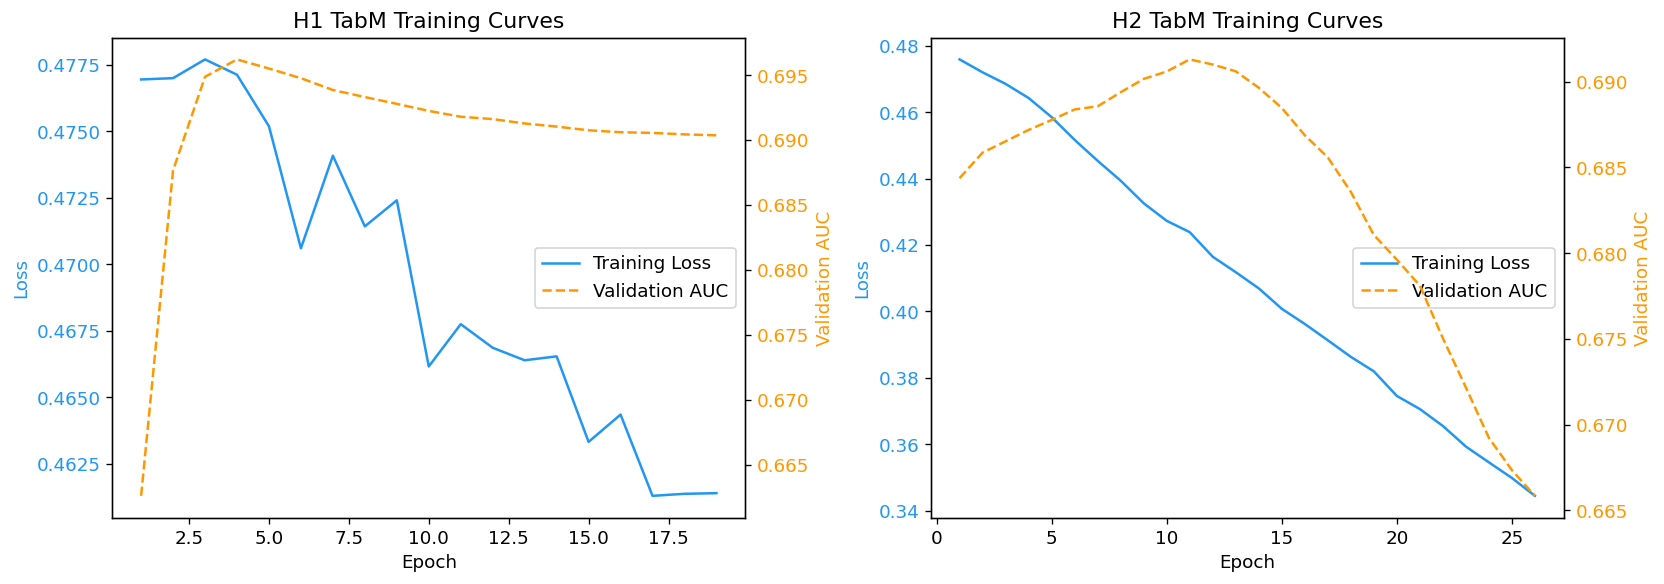

Saved: figures/13_tabm_training_curves.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, horizon in enumerate(['H1', 'H2']):
    curves_key = (horizon, 'TabM_curves')
    if curves_key not in trained_models:
        print(f"No TabM curves for {horizon}")
        continue
    curves = trained_models[curves_key]
    train_losses = curves['train_losses']
    val_aucs = curves['val_aucs']

    ax1 = axes[i]
    color1 = '#2196F3'
    color2 = '#FF9800'

    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, color=color1, label='Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_title(f'{horizon} TabM Training Curves')

    ax2 = ax1.twinx()
    val_epochs = range(1, len(val_aucs) + 1)
    ax2.plot(val_epochs, val_aucs, color=color2,
             label='Validation AUC', linestyle='--')
    ax2.set_ylabel('Validation AUC', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

    print(f"{horizon} TabM: {len(train_losses)} epochs, best val AUC={max(val_aucs):.4f}")

plt.tight_layout()
plt.savefig('../figures/13_tabm_training_curves.png', bbox_inches='tight')
plt.show()
print("Saved: figures/13_tabm_training_curves.png")


## 4.7 Save Results and Models

In [21]:
# ── Save full results table ────────────────────────────────────────
results_df = results.to_dataframe()
results_df.to_csv(DATA_DIR / 'modelling_results.csv', index=False)
print(f"Results saved: {len(results_df)} rows")
display(results_df)

# ── Save trained models via joblib (TabM via torch.save) ──────────
import torch
for key, model_or_pipe in trained_models.items():
    h, name = key
    if name.startswith('Dummy') or name.endswith('_curves'):
        continue
    safe_name = name.replace('(', '').replace(')', '').replace(' ', '_')
    if name == 'TabM':
        path = MODEL_DIR / f"{h}_{safe_name}.pt"
        torch.save({
            'model_state': model_or_pipe.model.state_dict(),
            'preprocessor': model_or_pipe.preprocessor,
        }, path)
    else:
        path = MODEL_DIR / f"{h}_{safe_name}.joblib"
        joblib.dump(model_or_pipe, path)
    print(f"Saved: {path}")

# ── Save best hyperparameters ──────────────────────────────────────
import json
params_out = {}
for key, params in best_params.items():
    h, name = key
    params_serializable = {}
    for k, v in params.items():
        if isinstance(v, (np.integer,)):
            params_serializable[k] = int(v)
        elif isinstance(v, (np.floating,)):
            params_serializable[k] = float(v)
        elif isinstance(v, tuple):
            params_serializable[k] = list(v)
        else:
            params_serializable[k] = v
    params_out[f"{h}_{name}"] = params_serializable

with open(MODEL_DIR / 'best_params.json', 'w') as f:
    json.dump(params_out, f, indent=2)
print(f"\nBest params saved to {MODEL_DIR / 'best_params.json'}")


Results saved: 24 rows


,horizon,model,split,roc_auc,pr_auc,balanced_accuracy,f1,brier_score,ece
0,H1,Dummy(most_frequent),val,0.500000,0.503385,0.500000,0.669668,0.496615,0.000000
1,H1,Dummy(stratified),val,0.488785,0.497873,0.488785,0.560212,0.510154,0.178462
2,H1,LogisticRegression,val,0.679856,0.665456,0.591065,0.472727,0.236595,0.100480
3,H1,HistGradientBoosting,val,0.676159,0.679379,0.620011,0.637698,0.227478,0.049987
4,H1,CatBoost,val,0.702103,0.702757,0.633075,0.564774,0.224635,0.074585
5,H1,TabM,val,0.696207,0.684844,0.633581,0.614987,0.247914,0.128068
6,H2,Dummy(most_frequent),val,0.500000,0.503385,0.500000,0.669668,0.496615,0.000000
7,H2,Dummy(stratified),val,0.488785,0.497873,0.488785,0.560212,0.510154,0.178462
8,H2,LogisticRegression,val,0.673693,0.655778,0.602379,0.522124,0.233009,0.066178
9,H2,HistGradientBoosting,val,0.684800,0.683781,0.625624,0.668849,0.225032,0.046961


Saved: ../models/H1_LogisticRegression.joblib
Saved: ../models/H1_HistGradientBoosting.joblib
Saved: ../models/H1_CatBoost.joblib
Saved: ../models/H1_TabM.pt
Saved: ../models/H2_LogisticRegression.joblib


Saved: ../models/H2_HistGradientBoosting.joblib
Saved: ../models/H2_CatBoost.joblib
Saved: ../models/H2_TabM.pt


Saved: ../models/H3_LogisticRegression.joblib
Saved: ../models/H3_CatBoost.joblib

Best params saved to ../models/best_params.json


## 4.8 Modelling Summary and Next Steps

In [22]:
print("=" * 70)
print("PHASE 4 MODELLING SUMMARY")
print("=" * 70)

# Validation results pivot
print("\nValidation ROC-AUC by Horizon x Model:")
val_df = results.to_dataframe()
val_df = val_df[val_df['split'] == 'val']
pivot_val = val_df.pivot_table(index='model', columns='horizon', values='roc_auc').round(4)
display(pivot_val)

# Test results pivot
print("\nTest ROC-AUC by Horizon x Model:")
test_df = results.to_dataframe()
test_df = test_df[test_df['split'] == 'test']
if not test_df.empty:
    pivot_test = test_df.pivot_table(index='model', columns='horizon', values='roc_auc').round(4)
    display(pivot_test)

# Key findings
print("\nKey Findings:")
print("1. DummyClassifier confirms ~0.50 AUC baseline (sanity check passed)")

# Best model per horizon (val)
for h in ['H1', 'H2', 'H3']:
    h_df = val_df[val_df['horizon'] == h].sort_values('roc_auc', ascending=False)
    if not h_df.empty:
        best = h_df.iloc[0]
        print(f"2. {h} best model: {best['model']} (val ROC-AUC={best['roc_auc']:.4f})")

# Leakage gap
for model in ['LogisticRegression', 'CatBoost']:
    h1_rows = val_df[(val_df['horizon'] == 'H1') & (val_df['model'] == model)]
    h3_rows = val_df[(val_df['horizon'] == 'H3') & (val_df['model'] == model)]
    if not h1_rows.empty and not h3_rows.empty:
        gap = h3_rows.iloc[0]['roc_auc'] - h1_rows.iloc[0]['roc_auc']
        print(f"3. {model} leakage gap (H3-H1): {gap:+.4f}")

print("\nNext: Phase 5 (Evaluation) — SHAP, calibration, error analysis, cross-horizon figures")


PHASE 4 MODELLING SUMMARY

Validation ROC-AUC by Horizon x Model:


horizon,H1,H2,H3
model,,,
CatBoost,0.7021,0.7111,0.7783
Dummy(most_frequent),0.5000,0.5000,NaN
Dummy(stratified),0.4888,0.4888,NaN
HistGradientBoosting,0.6762,0.6848,NaN
LogisticRegression,0.6799,0.6737,0.7422
TabM,0.6962,0.6913,NaN



Test ROC-AUC by Horizon x Model:


horizon,H1,H2,H3
model,,,
CatBoost,0.6739,0.6995,0.7700
HistGradientBoosting,0.6589,0.6708,NaN
LogisticRegression,0.6650,0.6401,0.6831
TabM,0.6677,0.6741,NaN



Key Findings:
1. DummyClassifier confirms ~0.50 AUC baseline (sanity check passed)
2. H1 best model: CatBoost (val ROC-AUC=0.7021)
2. H2 best model: CatBoost (val ROC-AUC=0.7111)
2. H3 best model: CatBoost (val ROC-AUC=0.7783)
3. LogisticRegression leakage gap (H3-H1): +0.0624
3. CatBoost leakage gap (H3-H1): +0.0762

Next: Phase 5 (Evaluation) — SHAP, calibration, error analysis, cross-horizon figures
